In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 1000)

In [2]:
df_commercial_activity = pd.read_csv('../data/datasets_TFM + diccionario/customer_commercial_activity.csv', sep=',')
df_sociodemographics = pd.read_csv('../data/datasets_TFM + diccionario/customer_sociodemographics.csv', sep=',')
df_customer_products = pd.read_csv('../data/datasets_TFM + diccionario/customer_products.csv', sep=',')
df_sales = pd.read_csv('../data/datasets_TFM + diccionario/sales.csv', sep=',')

df_product_description = pd.read_csv('../data/datasets_TFM + diccionario/product_description.csv', sep=',')

In [3]:
df_commercial_activity.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
df_sociodemographics.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
df_customer_products.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
df_sales.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
df_product_description.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

# 1. Preprocessing + FE

### CUSTOMER DATA

In [4]:
df = df_commercial_activity.merge(df_sociodemographics, how='left', on = ['pk_cid','pk_partition'])
df = df.merge(df_customer_products, how='left', on = ['pk_cid','pk_partition'])
df

,pk_cid,pk_partition,entry_date,entry_channel,active_customer,segment,country_id,region_code,gender,age,deceased,salary,short_term_deposit,loans,mortgage,funds,securities,long_term_deposit,em_account_pp,credit_card,payroll,pension_plan,payroll_account,emc_account,debit_card,em_account_p,em_acount
0,1375586,2018-01,2018-01,KHL,1.0,02 - PARTICULARES,ES,29.0,H,35,N,87218.10,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,1
1,1050611,2018-01,2015-08,KHE,0.0,03 - UNIVERSITARIO,ES,13.0,V,23,N,35548.74,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,1
2,1050612,2018-01,2015-08,KHE,0.0,03 - UNIVERSITARIO,ES,13.0,V,23,N,122179.11,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,1
3,1050613,2018-01,2015-08,KHD,0.0,03 - UNIVERSITARIO,ES,50.0,H,22,N,119775.54,1,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,0
4,1050614,2018-01,2015-08,KHE,1.0,03 - UNIVERSITARIO,ES,50.0,V,23,N,NaN,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5962919,1166765,2019-05,2016-08,KHE,0.0,03 - UNIVERSITARIO,ES,50.0,V,22,N,43912.17,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,1
5962920,1166764,2019-05,2016-08,KHE,0.0,03 - UNIVERSITARIO,ES,26.0,V,23,N,23334.99,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,1
5962921,1166763,2019-05,2016-08,KHE,1.0,02 - PARTICULARES,ES,50.0,H,47,N,NaN,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,1
5962922,1166789,2019-05,2016-08,KHE,0.0,03 - UNIVERSITARIO,ES,50.0,H,22,N,199592.82,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,1


In [5]:
print("Número de registros: {}".format(df.pk_cid.count())) #5.962.924
print("Número de ids únicos: {}".format(df.pk_cid.nunique())) #456.373
print("Número de particiones únicos: {}".format(df.pk_partition.nunique())) #17

Número de registros: 5962924
Número de ids únicos: 456373
Número de particiones únicos: 17


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5962924 entries, 0 to 5962923
Data columns (total 27 columns):
 #   Column              Dtype  
---  ------              -----  
 0   pk_cid              int64  
 1   pk_partition        object 
 2   entry_date          object 
 3   entry_channel       object 
 4   active_customer     float64
 5   segment             object 
 6   country_id          object 
 7   region_code         float64
 8   gender              object 
 9   age                 int64  
 10  deceased            object 
 11  salary              float64
 12  short_term_deposit  int64  
 13  loans               int64  
 14  mortgage            int64  
 15  funds               int64  
 16  securities          int64  
 17  long_term_deposit   int64  
 18  em_account_pp       int64  
 19  credit_card         int64  
 20  payroll             float64
 21  pension_plan        float64
 22  payroll_account     int64  
 23  emc_account         int64  
 24  debit_card          int6

In [7]:
df.describe()

,pk_cid,active_customer,region_code,age,salary,short_term_deposit,loans,mortgage,funds,securities,long_term_deposit,em_account_pp,credit_card,payroll,pension_plan,payroll_account,emc_account,debit_card,em_account_p,em_acount
count,5.962924e+06,5.962924e+06,5.960660e+06,5.962924e+06,4.421820e+06,5.962924e+06,5.962924e+06,5.962924e+06,5.962924e+06,5.962924e+06,5.962924e+06,5962924.0,5.962924e+06,5.962863e+06,5.962863e+06,5.962924e+06,5.962924e+06,5.962924e+06,5.962924e+06,5.962924e+06
mean,1.234930e+06,4.033845e-01,2.581440e+01,2.976042e+01,1.155833e+05,2.581619e-03,7.848498e-05,5.433576e-05,3.370662e-03,3.711770e-03,1.688098e-02,0.0,1.188444e-02,3.451144e-02,3.652641e-02,5.524471e-02,5.483233e-02,9.441140e-02,5.701901e-06,7.348076e-01
std,1.623020e+05,4.905767e-01,1.359566e+01,1.198038e+01,2.000066e+05,5.074401e-02,8.858828e-03,7.371080e-03,5.795948e-02,6.081113e-02,1.288255e-01,0.0,1.083660e-01,1.825388e-01,1.875960e-01,2.284573e-01,2.276527e-01,2.924002e-01,2.387859e-03,4.414356e-01
min,1.589100e+04,0.000000e+00,1.000000e+00,2.000000e+00,1.202730e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.112532e+06,0.000000e+00,1.300000e+01,2.200000e+01,6.141532e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.231097e+06,0.000000e+00,2.800000e+01,2.500000e+01,8.844147e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.352339e+06,1.000000e+00,3.600000e+01,3.400000e+01,1.313092e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
max,1.553689e+06,1.000000e+00,5.200000e+01,1.050000e+02,2.889440e+07,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [8]:
df["pk_cid"] = df["pk_cid"].astype(str)

#### -> Imputación de nulos

In [9]:
df.select_dtypes(include=['number']).isnull().sum().sort_values(ascending=False)

salary                1541104
region_code              2264
pension_plan               61
payroll                    61
active_customer             0
credit_card                 0
em_account_p                0
debit_card                  0
emc_account                 0
payroll_account             0
long_term_deposit           0
em_account_pp               0
securities                  0
funds                       0
mortgage                    0
loans                       0
short_term_deposit          0
age                         0
em_acount                   0
dtype: int64

In [10]:
df.select_dtypes(include=['object']).isnull().sum().sort_values(ascending=False)

segment          133944
entry_channel    133033
gender               25
pk_cid                0
pk_partition          0
entry_date            0
country_id            0
deceased              0
dtype: int64

In [11]:
cols_with_nulls = ['salary','region_code']

for col in cols_with_nulls:
    null_pct = (df[col].isnull().sum() / len(df)) * 100
    print(f'% de nulos en {col}: {null_pct:.2f}%')

% de nulos en salary: 25.84%
% de nulos en region_code: 0.04%


In [12]:
df["salary"].describe()

count    4.421820e+06
mean     1.155833e+05
std      2.000066e+05
min      1.202730e+03
25%      6.141532e+04
50%      8.844147e+04
75%      1.313092e+05
max      2.889440e+07
Name: salary, dtype: float64

In [13]:
print("Salario medio:",df.groupby('pk_partition')["salary"].mean())
print("Salario mediana:",df.groupby('pk_partition')["salary"].median())

Salario medio: pk_partition
2018-01    112895.921277
2018-02    112898.096583
2018-03    113014.244875
2018-04    113035.403641
2018-05    113163.092118
2018-06    113254.941003
2018-07    117002.514965
2018-08    116590.408860
2018-09    116501.778626
2018-10    116488.825331
2018-11    116487.545163
2018-12    116493.811517
2019-01    116459.138496
2019-02    116453.510931
2019-03    116454.999778
2019-04    116455.702046
2019-05    116461.103930
Name: salary, dtype: float64
Salario mediana: pk_partition
2018-01    87375.390
2018-02    87429.030
2018-03    87471.150
2018-04    87535.020
2018-05    87568.950
2018-06    87598.140
2018-07    89105.100
2018-08    88864.455
2018-09    88821.300
2018-10    88813.455
2018-11    88804.065
2018-12    88803.840
2019-01    88811.595
2019-02    88811.400
2019-03    88806.090
2019-04    88803.840
2019-05    88796.610
Name: salary, dtype: float64


In [14]:
#los menores no tienen salario ninguno
df[(df["age"]<18)&(df["salary"].notna())]

,pk_cid,pk_partition,entry_date,entry_channel,active_customer,segment,country_id,region_code,gender,age,deceased,salary,short_term_deposit,loans,mortgage,funds,securities,long_term_deposit,em_account_pp,credit_card,payroll,pension_plan,payroll_account,emc_account,debit_card,em_account_p,em_acount


In [15]:
#en cambio, los jubilados sí 
df[(df["age"]>70)&(df["salary"].notna())]

,pk_cid,pk_partition,entry_date,entry_channel,active_customer,segment,country_id,region_code,gender,age,deceased,salary,short_term_deposit,loans,mortgage,funds,securities,long_term_deposit,em_account_pp,credit_card,payroll,pension_plan,payroll_account,emc_account,debit_card,em_account_p,em_acount
600,1050360,2018-01,2015-08,KFA,1.0,01 - TOP,ES,28.0,H,84,N,113431.50,0,0,0,0,0,0,0,0,0.0,1.0,1,1,1,0,0
646,1051920,2018-01,2015-08,KFA,1.0,02 - PARTICULARES,ES,28.0,V,83,N,242314.05,0,0,0,0,0,0,0,0,0.0,0.0,0,1,0,0,0
684,1051839,2018-01,2015-08,KAT,1.0,02 - PARTICULARES,ES,28.0,H,77,N,56336.46,0,0,0,0,0,1,0,0,0.0,0.0,0,1,0,0,1
898,1052168,2018-01,2015-08,KFC,1.0,02 - PARTICULARES,ES,28.0,V,78,N,97854.24,0,0,0,0,0,0,0,0,0.0,1.0,1,0,0,0,0
1157,1051398,2018-01,2015-08,KFC,1.0,01 - TOP,ES,28.0,H,73,N,226134.57,0,0,0,0,0,0,0,1,0.0,0.0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5961382,1167357,2019-05,2016-08,KAT,1.0,02 - PARTICULARES,ES,50.0,V,87,N,123103.32,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,1
5961626,1168259,2019-05,2016-08,KFC,1.0,02 - PARTICULARES,ES,43.0,H,75,N,45516.36,0,0,0,0,0,1,0,0,0.0,0.0,0,0,0,0,1
5962164,1166595,2019-05,2016-08,KHE,0.0,02 - PARTICULARES,ES,46.0,H,88,N,106387.71,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,0
5962442,1166276,2019-05,2016-08,KFA,1.0,02 - PARTICULARES,ES,28.0,V,73,N,307197.27,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,0


In [16]:
# 1. Variables numericas

# 1.1 salario
median_salary_cid = df.groupby('pk_cid')['salary'].median()
median_salary_regioncode = df.groupby('region_code')['salary'].median()

df.loc[(df["age"]<18)&(df["salary"].isna()), 'salary'] = 0 # vemos que todos los menores tienen el salary null, lo imputamos con 0
df['salary'] = df['salary'].fillna(df['pk_cid'].map(median_salary_cid))
df['salary'] = df['salary'].fillna(df['region_code'].map(median_salary_regioncode))
df['salary'] = df['salary'].fillna(df['salary'].median())  # fallback global

# 1.2 region_code (no es realmente numerica)
mode_region_cid = df.groupby('pk_cid')['region_code'].agg(lambda x: x.mode().iloc[0] if len(x.mode()) else np.nan)
mode_region_es = df[df['country_id'] == 'ES'].groupby('pk_partition')['region_code'].agg(lambda x: x.mode().iloc[0] if len(x.mode()) else np.nan)

def fill_region(row):
    if pd.notna(row['region_code']):
        return row['region_code']
    
    cid_mode = mode_region_cid.get(row['pk_cid'], np.nan)
    if pd.notna(cid_mode):
        return cid_mode
    
    if row['country_id'] == 'ES':
        return mode_region_es.get(row['pk_partition'], np.nan)
    else:
        return -1

df['region_code'] = df.apply(fill_region, axis=1)


# 1.3 para todo producto que no tenga valor, lo imputamos como 0
product_cols = ['short_term_deposit', 'loans', 'mortgage',
       'funds', 'securities', 'long_term_deposit', 'em_account_pp',
       'credit_card', 'payroll', 'pension_plan', 'payroll_account',
       'emc_account', 'debit_card', 'em_account_p', 'em_acount']

for col in product_cols:
    df[col] = df[col].fillna(0)


In [17]:
# 2. Variables categóricas

# 2.1 rellenamos los pocos nulos que hay con la moda de su partición
mode_segment = df.groupby('pk_partition')['segment'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
mode_channel = df.groupby('pk_partition')['entry_channel'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)

df['segment'] = df['segment'].fillna(df['pk_partition'].map(mode_segment))
df['entry_channel'] = df['entry_channel'].fillna(df['pk_partition'].map(mode_channel)) 

# 2.2 geneder
mode_gender_cid = df.groupby('pk_cid')['gender'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
mode_gender_partition = df.groupby('pk_partition')['gender'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)

df['gender'] = df['gender'].fillna(df['pk_cid'].map(mode_gender_cid))
df['gender'] = df['gender'].fillna(df['pk_partition'].map(mode_gender_partition))
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])  # fallback global


In [18]:
df.select_dtypes(include=['number']).isnull().sum().sort_values(ascending=False)

active_customer       0
em_account_pp         0
em_account_p          0
debit_card            0
emc_account           0
payroll_account       0
pension_plan          0
payroll               0
credit_card           0
long_term_deposit     0
region_code           0
securities            0
funds                 0
mortgage              0
loans                 0
short_term_deposit    0
salary                0
age                   0
em_acount             0
dtype: int64

In [19]:
df.select_dtypes(include=['object']).isnull().sum().sort_values(ascending=False)

pk_cid           0
pk_partition     0
entry_date       0
entry_channel    0
segment          0
country_id       0
gender           0
deceased         0
dtype: int64

In [20]:
print("Número de registros: {}".format(df.pk_cid.count())) #5.962.924
print("Número de ids únicos: {}".format(df.pk_cid.nunique())) #456.373
print("Número de particiones únicos: {}".format(df.pk_partition.nunique())) #17

Número de registros: 5962924
Número de ids únicos: 456373
Número de particiones únicos: 17


#### -> Outliers

<Axes: xlabel='salary'>

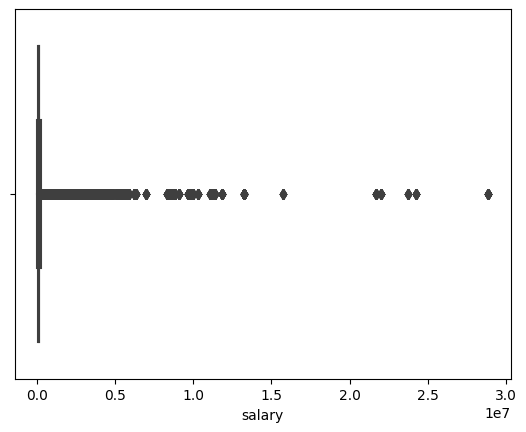

In [21]:
sns.boxplot(x=df["salary"])

In [22]:
df[df["salary"]>2000000].pk_cid.nunique()

179

<Axes: >

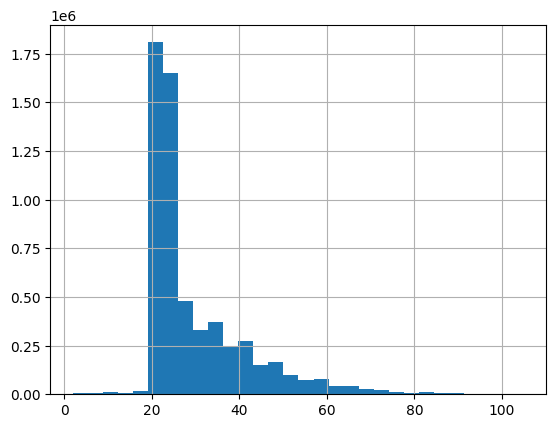

In [23]:
df["age"].hist(bins=30)

<Axes: xlabel='age'>

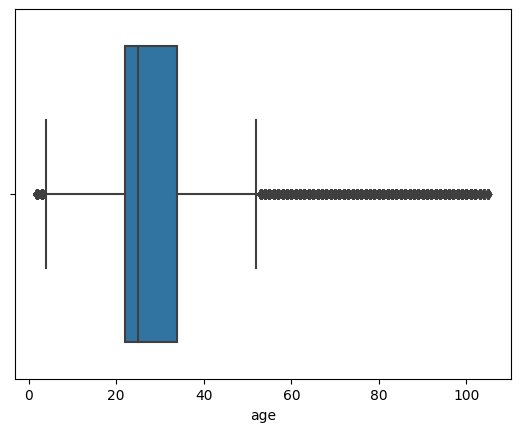

In [24]:
sns.boxplot(x=df["age"])

#### dtypes transformation

In [25]:
df['pk_partition'] = pd.to_datetime(df['pk_partition'], errors='coerce')
df['entry_date'] = pd.to_datetime(df['entry_date'], errors='coerce')

## New interesting features

* z_months_since_entry

In [26]:
df['z_months_since_entry'] = ((df['pk_partition'] - df['entry_date']).dt.days / 30).round()

* z_pct_months_active

In [27]:
df = df.sort_values(['pk_cid', 'pk_partition'])

df['active_flag'] = df['active_customer'].eq(1).astype(int)
df['cum_months_total'] = df.groupby('pk_cid').cumcount() + 1
df['cum_months_active'] = df.groupby('pk_cid')['active_flag'].cumsum()

# Calculamos el porcentaje incremental
df['z_pct_months_active'] = (df['cum_months_active'] / df['cum_months_total']).round(2)
df = df.drop(columns=['active_flag', 'cum_months_total', 'cum_months_active'])

* z_segment_mode

In [28]:
df = df.sort_values(['pk_cid', 'pk_partition'])

# Detectar cambios de segmento
df['segment_prev'] = df.groupby('pk_cid')['segment'].shift(1)
df['z_partition_segment_changed'] = ((df['segment'] != df['segment_prev']) & df['segment_prev'].notna()).astype(int)


df['z_segment_mode'] = (
    df.groupby('pk_cid')['segment']
    .transform(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA)
)

df = df.drop(columns=['segment_prev'])

* z_churn_customer_flag

In [29]:
df = df.sort_values(['pk_cid', 'pk_partition'])

df['next_partition'] = df.groupby('pk_cid')['pk_partition'].shift(-1)
last_partition = df['pk_partition'].max()

df['z_churn_customer_flag'] = np.where(
    df['next_partition'].isna() &
    (df['pk_partition'] != last_partition),
    1, 
    0
)

df = df.drop(columns=['next_partition'])

* z_new_customer_flag

In [30]:
df['z_new_customer_flag'] = (df['z_months_since_entry'] == 0).astype(int)

* z_num_products

In [31]:
df['z_num_products'] = df[product_cols].sum(axis=1)

In [32]:
df[df["z_num_products"] == 0]["active_customer"].value_counts()

active_customer
0.0    1059439
1.0      62068
Name: count, dtype: int64

In [33]:
df[(df["z_num_products"] == 0) & (df["active_customer"] == 1)]

,pk_cid,pk_partition,entry_date,entry_channel,active_customer,segment,country_id,region_code,gender,age,deceased,salary,short_term_deposit,loans,mortgage,funds,securities,long_term_deposit,em_account_pp,credit_card,payroll,pension_plan,payroll_account,emc_account,debit_card,em_account_p,em_acount,z_months_since_entry,z_pct_months_active,z_partition_segment_changed,z_segment_mode,z_churn_customer_flag,z_new_customer_flag,z_num_products
83191,1000096,2018-01-01,2015-01-01,KFA,1.0,02 - PARTICULARES,ES,28.0,H,9,N,0.00,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,37.0,1.00,0,02 - PARTICULARES,0,0,0.0
398332,1000096,2018-02-01,2015-01-01,KFA,1.0,02 - PARTICULARES,ES,28.0,H,9,N,0.00,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,38.0,1.00,0,02 - PARTICULARES,0,0,0.0
648484,1000096,2018-03-01,2015-01-01,KFA,1.0,02 - PARTICULARES,ES,28.0,H,9,N,0.00,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,38.0,1.00,0,02 - PARTICULARES,0,0,0.0
889463,1000096,2018-04-01,2015-01-01,KFA,1.0,02 - PARTICULARES,ES,28.0,H,9,N,0.00,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,40.0,1.00,0,02 - PARTICULARES,0,0,0.0
1055077,1000096,2018-05-01,2015-01-01,KFA,1.0,02 - PARTICULARES,ES,28.0,H,9,N,0.00,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,41.0,1.00,0,02 - PARTICULARES,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3330555,994005,2018-11-01,2018-08-01,KHN,1.0,02 - PARTICULARES,ES,28.0,V,38,N,109253.34,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,3.0,0.75,0,02 - PARTICULARES,0,0,0.0
3389655,994005,2018-12-01,2018-08-01,KHN,1.0,02 - PARTICULARES,ES,28.0,V,38,N,109253.34,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,4.0,0.80,0,02 - PARTICULARES,0,0,0.0
2662886,995335,2018-10-01,2015-01-01,KAT,1.0,02 - PARTICULARES,ES,41.0,H,66,N,47631.93,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,46.0,1.00,0,02 - PARTICULARES,1,0,0.0
1817264,998252,2018-08-01,2015-01-01,KAT,1.0,02 - PARTICULARES,ES,8.0,H,41,N,190669.23,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,44.0,1.00,0,02 - PARTICULARES,0,0,0.0


* z_active_with_product

In [34]:
# Creamos nueva variable de actividad 
# Si el cliente no tiene ningún producto realmente no es cliente activo
df['z_active_with_product'] = (~(df[product_cols] == 0).all(axis=1)).astype(int)

In [35]:
df[(df["z_num_products"] == 0) & (df["z_active_with_product"] == 1)]

,pk_cid,pk_partition,entry_date,entry_channel,active_customer,segment,country_id,region_code,gender,age,deceased,salary,short_term_deposit,loans,mortgage,funds,securities,long_term_deposit,em_account_pp,credit_card,payroll,pension_plan,payroll_account,emc_account,debit_card,em_account_p,em_acount,z_months_since_entry,z_pct_months_active,z_partition_segment_changed,z_segment_mode,z_churn_customer_flag,z_new_customer_flag,z_num_products,z_active_with_product


In [36]:
print("Número de registros: {}".format(df.pk_cid.count())) #5.962.924
print("Número de ids únicos: {}".format(df.pk_cid.nunique())) #456.373
print("Número de particiones únicos: {}".format(df.pk_partition.nunique())) #17

Número de registros: 5962924
Número de ids únicos: 456373
Número de particiones únicos: 17


### SALES

In [37]:
df_sales = df_sales.merge(df_product_description, how='left', left_on ="product_ID", right_on="pk_product_ID")
df_sales.drop(columns="pk_product_ID", inplace=True)

str_cols = ["pk_sale","cid", "product_ID"]
for col in str_cols:
    df_sales[col] = df_sales[col].astype(str)

df_sales['month_sale'] = pd.to_datetime(df_sales['month_sale'], errors='coerce')

* Creación del futuro target de cada producto y familia

In [38]:
df_sales

,pk_sale,cid,month_sale,product_ID,net_margin,product_desc,family_product
0,6666,33620,2018-05-01,2335,952.9,short_term_deposit,investment
1,6667,35063,2018-06-01,2335,1625.2,short_term_deposit,investment
2,6668,37299,2018-02-01,2335,1279.7,short_term_deposit,investment
3,6669,39997,2018-02-01,2335,1511.9,short_term_deposit,investment
4,6670,44012,2018-02-01,2335,1680.3,short_term_deposit,investment
...,...,...,...,...,...,...,...
240768,247434,1553456,2019-05-01,4657,56.7,em_acount,account
240769,247435,1553541,2019-05-01,4657,66.5,em_acount,account
240770,247436,1553559,2019-05-01,4657,73.0,em_acount,account
240771,247437,1553565,2019-05-01,4657,82.3,em_acount,account


In [39]:
df_sales['indicator'] = 1

# pivoy table para product_desc 
pivot_products = (
    df_sales.pivot_table(
        index=['cid', 'month_sale'],
        columns='product_desc',
        values='indicator',
        aggfunc='max',   #si existe, vale 1
        fill_value=0
    )
)

# pivot table para family_product (puede haber más de una venta por familia pero dejamos un 1)
pivot_families = (
    df_sales.pivot_table(
        index=['cid', 'month_sale'],
        columns='family_product',
        values='indicator',
        aggfunc='max',
        fill_value=0
    )
)

pivot_products.columns = [f'y_{col}' for col in pivot_products.columns]
pivot_families.columns = [f'y_fam_{col}' for col in pivot_families.columns]
df_pivot = pd.concat([pivot_products, pivot_families], axis=1).reset_index()

for c in df_pivot.columns:
    if c not in ['cid', 'month_sale']:
        df_pivot[c] = df_pivot[c].astype(int)

df_pivot.rename(columns={"cid":"pk_cid", "month_sale":"pk_partition"}, inplace=True)


In [40]:
ventas_por_mes = (
    df_sales
    .groupby(['cid', 'month_sale'])['product_ID']
    .count()
    .reset_index(name='num_ventas')
)
ventas_por_mes.rename(columns={"cid":"pk_cid", "month_sale":"pk_partition","num_ventas":"z_num_purchased_products"}, inplace=True)
ventas_por_mes[ventas_por_mes['z_num_purchased_products'] > 1]

,pk_cid,pk_partition,z_num_purchased_products
3,1000391,2018-02-01,2
15,1000468,2018-07-01,2
17,1000479,2018-10-01,3
23,1000502,2018-09-01,2
29,1000527,2019-01-01,2
...,...,...,...
202671,986296,2018-12-01,2
202674,991354,2019-02-01,4
202683,994005,2018-09-01,2
202685,994920,2018-04-01,2


## UNION 

In [41]:
df = df.merge(ventas_por_mes, how = "left", on = ["pk_cid", "pk_partition"]).fillna(0)
df = df.merge(df_pivot, how = "left", on = ["pk_cid", "pk_partition"]).fillna(0)

In [42]:
df.head()

,pk_cid,pk_partition,entry_date,entry_channel,active_customer,segment,country_id,region_code,gender,age,deceased,salary,short_term_deposit,loans,mortgage,funds,securities,long_term_deposit,em_account_pp,credit_card,payroll,pension_plan,payroll_account,emc_account,debit_card,em_account_p,em_acount,z_months_since_entry,z_pct_months_active,z_partition_segment_changed,z_segment_mode,z_churn_customer_flag,z_new_customer_flag,z_num_products,z_active_with_product,z_num_purchased_products,y_credit_card,y_debit_card,y_em_acount,y_emc_account,y_funds,y_loans,y_long_term_deposit,y_mortgage,y_payroll,y_payroll_account,y_pension_plan,y_securities,y_short_term_deposit,y_fam_account,y_fam_investment,y_fam_loan,y_fam_payment_card,y_fam_pension_plan
0,1000028,2018-01-01,2017-01-01,KHC,1.0,02 - PARTICULARES,ES,28.0,H,43,N,133378.89,0,0,0,0,0,0,0,0,0.0,0.0,0,0,1,0,1,12.0,1.0,0,02 - PARTICULARES,0,0,2.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1000028,2018-02-01,2017-01-01,KHC,1.0,02 - PARTICULARES,ES,28.0,H,43,N,133378.89,0,0,0,0,0,0,0,0,0.0,0.0,0,0,1,0,1,13.0,1.0,0,02 - PARTICULARES,0,0,2.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1000028,2018-03-01,2017-01-01,KHC,1.0,02 - PARTICULARES,ES,28.0,H,43,N,133378.89,0,0,0,0,0,0,0,0,0.0,0.0,0,0,1,0,1,14.0,1.0,0,02 - PARTICULARES,0,0,2.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1000028,2018-04-01,2017-01-01,KHC,1.0,02 - PARTICULARES,ES,28.0,H,43,N,133378.89,0,0,0,0,0,0,0,0,0.0,0.0,0,0,1,0,1,15.0,1.0,0,02 - PARTICULARES,0,0,2.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1000028,2018-05-01,2017-01-01,KHC,1.0,02 - PARTICULARES,ES,28.0,H,43,N,133378.89,0,0,0,0,0,0,0,0,0.0,0.0,0,0,1,0,1,16.0,1.0,0,02 - PARTICULARES,0,0,2.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [43]:
print("Número de registros: {}".format(df.pk_cid.count())) #5.962.924
print("Número de ids únicos: {}".format(df.pk_cid.nunique())) #456.373
print("Número de particiones únicos: {}".format(df.pk_partition.nunique())) #17

Número de registros: 5962924
Número de ids únicos: 456373
Número de particiones únicos: 17


# 2. Data Preparation for future Modelling

In [44]:
# product_target = 'pension_plan'
product_target = 'fam_investment'

In [ ]:
if product_target not in df.columns: # para productos únicos
    short_target = product_target.split("fam_")[1]
    products = df_sales.loc[df_sales["family_product"] == short_target, "product_desc"].drop_duplicates().tolist()
    print(products)

In [46]:
cols_y = [c for c in df.columns if c.startswith("y_") and c != "y_" + product_target]

if product_target in df.columns: # para productos únicos
    df = df.drop(columns=cols_y + [product_target])
else: # para familias
    df = df.drop(columns=cols_y + products)

In [47]:
# ejemplo y_pension_plan = 1 y _pension_plan = 0
#df[df["pk_cid"].isin([1000391, 1000028])].sort_values(by=['pk_cid','pk_partition'])

In [48]:
# detectamos mes de contratación
df = df.sort_values(["pk_cid", "pk_partition"])
df["did_contract"] = df.groupby("pk_cid")["y_" + product_target].transform("max")

df_contract = df[df["did_contract"] == 1]
df_nocontract = df[df["did_contract"] == 0]

In [49]:
# 1.1 para clientes que contrataron cogemos la partición anterior:
first_contract = df_contract[df_contract["y_" + product_target] == 1].groupby("pk_cid")["pk_partition"].min()

df_contract_prevmonth = (
    df_contract
    .merge(first_contract.rename("contract_month"), on="pk_cid")
    .query("pk_partition < contract_month")
)

df_contract_prevmonth = (
    df_contract_prevmonth.sort_values(["pk_cid", "pk_partition"])
    .groupby("pk_cid")
    .tail(1)
)

In [50]:
# 1.2 para clientes que no contrataron cogemos todas sus particiones
df_neg = df_nocontract.copy()

In [51]:
df_model = pd.concat([df_neg, df_contract_prevmonth], ignore_index=True).drop(columns={"y_" + product_target,"contract_month"})
df_model = df_model.rename(columns={"did_contract":"y"})

In [52]:
print(len(df), len(df_model))
print(df.pk_cid.nunique(), df_model.pk_cid.nunique())

5962924 5849004
456373 453789


In [53]:
save_path = 'data/df_' + product_target + '.csv'
save_path

'data/df_fam_investment.csv'

In [54]:
# apartir de aquí, hacer transformaciones de variables (ej. encodings) y luego modelar
df_model.to_csv(save_path)